In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import seaborn as sns

import os
import sys
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))
from plot_phases import plot_critical

def find_f_and_s(f_type, s_type):
    if f_type == "small":
        fs = [0.00001, 0.0001, 0.001, 0.01]
    else:
        fs = [0.98, 0.985, 0.99, 0.995, 1.0]
    if s_type == "small":
        ss = [0.00001, 0.0001, 0.001, 0.01]
    else:
        ss = [10, 100, 1000, 10000, 100000, 1000000]
    return fs, ss

In [ ]:
# === Configuration ===
data_root = Path("SQUARE")  # adjust to where your results live
output_root = Path("combined_results")
output_root.mkdir(exist_ok=True, parents=True)

# Known parameter arrays
FLEX_STRENGTH_values = [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01]
# FLEX_STRENGTH_values = [0.98, 0.985, 0.99, 0.995, 0.999, 0.9995, 0.9999]
# S_values = [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01]
S_values = [10, 100, 1000, 10000, 100000, 1000000]

# --- Helpers ---

def fmt_folder_val(x: float) -> str:
    """
    Format a float for folder name like:
    0.05 -> flex005, 0.1 -> flex01, 0.995 -> flex0995
    """
    if x == 1.0:
        return "10"
    return str(x).replace('.', 'p')

def fmt_val(x: float, d: int) -> str:
    """Format float for filename (S and F inside .npz)"""
    if x == 1.0:
        return "1"
    s = f"{x:.{d}f}".rstrip('0').rstrip('p')
    return s.replace('.', 'p')

def combine_arrays(arrs, stds, n=20):
    """Combine replicate means and stds across replicates."""
    arrs = np.stack(arrs)
    stds = np.stack(stds)
    K = arrs.shape[0]
    means = arrs.mean(axis=0)

    SS_within = ((n - 1) * stds**2).sum(axis=0)
    SS_between = (n * (arrs - means)**2).sum(axis=0)

    pooled_var = (SS_within + SS_between) / (K * n - 1)
    pooled_std = np.sqrt(pooled_var)
    return means, pooled_std

# --- Combination loop ---

summary_rows = []
total_tasks = len(FLEX_STRENGTH_values) * len(S_values)

with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
    for S in S_values:
        f_dir = data_root / f"s{fmt_folder_val(S)}"
        if not f_dir.exists():
            tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={S} ({f_dir})")
            pbar.update(len(FLEX_STRENGTH_values))
            continue

        for F in FLEX_STRENGTH_values:
            s_str = f"{S:.6f}".replace('.', 'p').rstrip('0').rstrip('p')
            f_str = f"{F:.6f}".replace('.', 'p').rstrip('0').rstrip('p')
            pattern = f"*S{s_str}_flex{f_str}_*.npz"
            files = list(f_dir.glob(pattern))
            pbar.update(1)

            if not files:
                tqdm.write(f"⚠️  No files for S={S}, F={F}: {pattern}")
                continue

            data = [np.load(f) for f in files]
            keys = ["T0", "T1", "T2", "T3", "CD"]
            combined = {}

            for k in keys:
                means = [d[k] for d in data]
                stds = [d[f"{k}_std"] for d in data]
                m, s = combine_arrays(means, stds)
                combined[k] = m
                combined[f"{k}_std"] = s

            # Save combined time-series .npz
            out_npz = output_root / f"COMBINED_S{s_str}_F{f_str}.npz"
            np.savez_compressed(out_npz, **combined, S=S, F=F)

            # Store final-timestep summary
            final = {k: combined[k][-1] for k in keys}
            final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
            summary_rows.append({"S": S, "F": F, **final, **final_std})


# === Write summary CSV ===
df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
df.to_csv(output_root / "summary_square_final_smallF_largeS.csv", index=False)

print(f"\n✅ Combined {len(summary_rows)} parameter groups")
print(f"📁 Results saved in: {output_root.resolve()}")

In [ ]:
data_dir = Path("combined_results")
files = {
    "summary_square_final_largeF_largeS.csv":  ("largeF", "largeS"),
    "summary_square_final_largeF_smallS.csv":  ("largeF", "smallS"),
    "summary_square_final_smallF_largeS.csv":  ("smallF", "largeS"),
    "summary_square_final_smallF_smallS.csv":  ("smallF", "smallS"),
}
dfs = []

for filename, (flex_size, s_size) in files.items():
    df = pd.read_csv(data_dir / filename)

    # Add metadata columns so you don't lose provenance
    df["FLEX_strength_group"] = flex_size
    df["S_group"] = s_size

    dfs.append(df)

# Combine all into one DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Save to CSV
combined_df.to_csv("summary_square_final_combined.csv", index=False)

<Figure size 1400x1000 with 0 Axes>

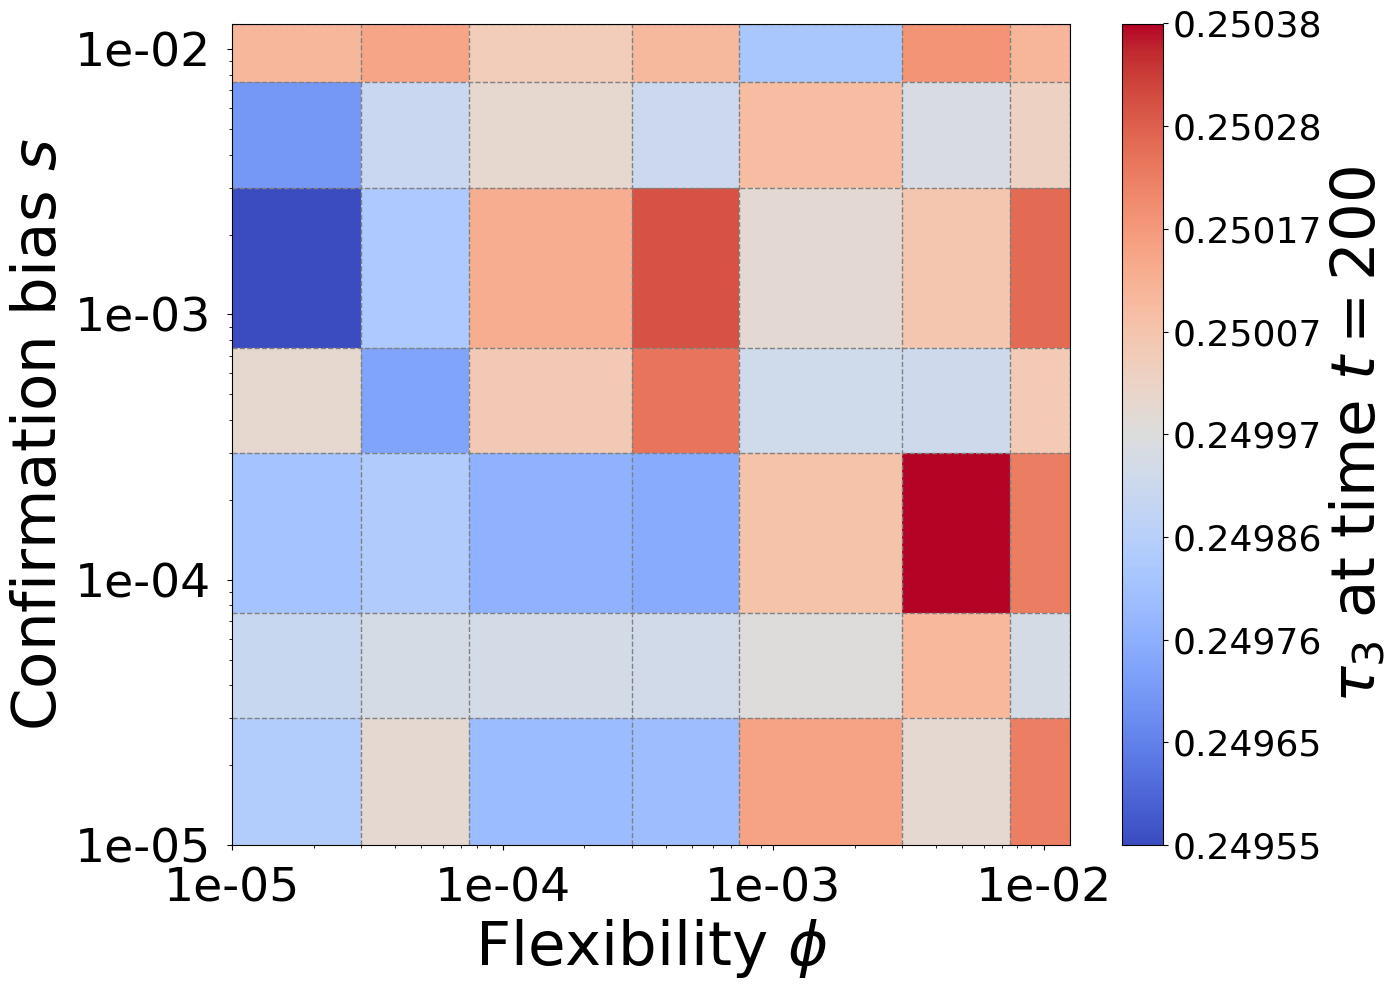

<Figure size 1400x1000 with 0 Axes>

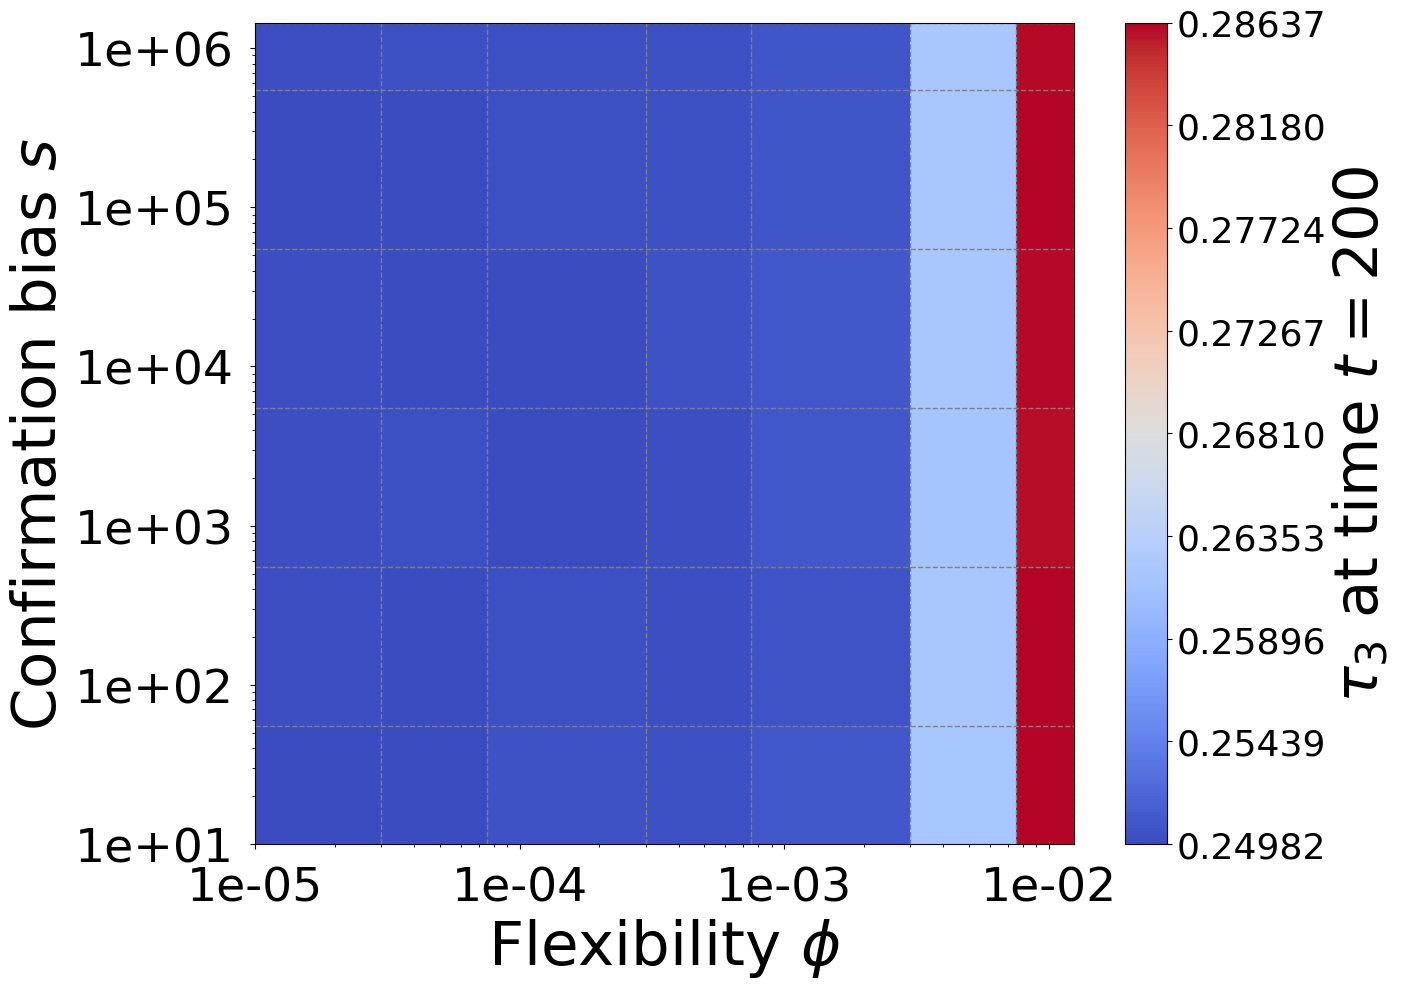

<Figure size 1400x1000 with 0 Axes>

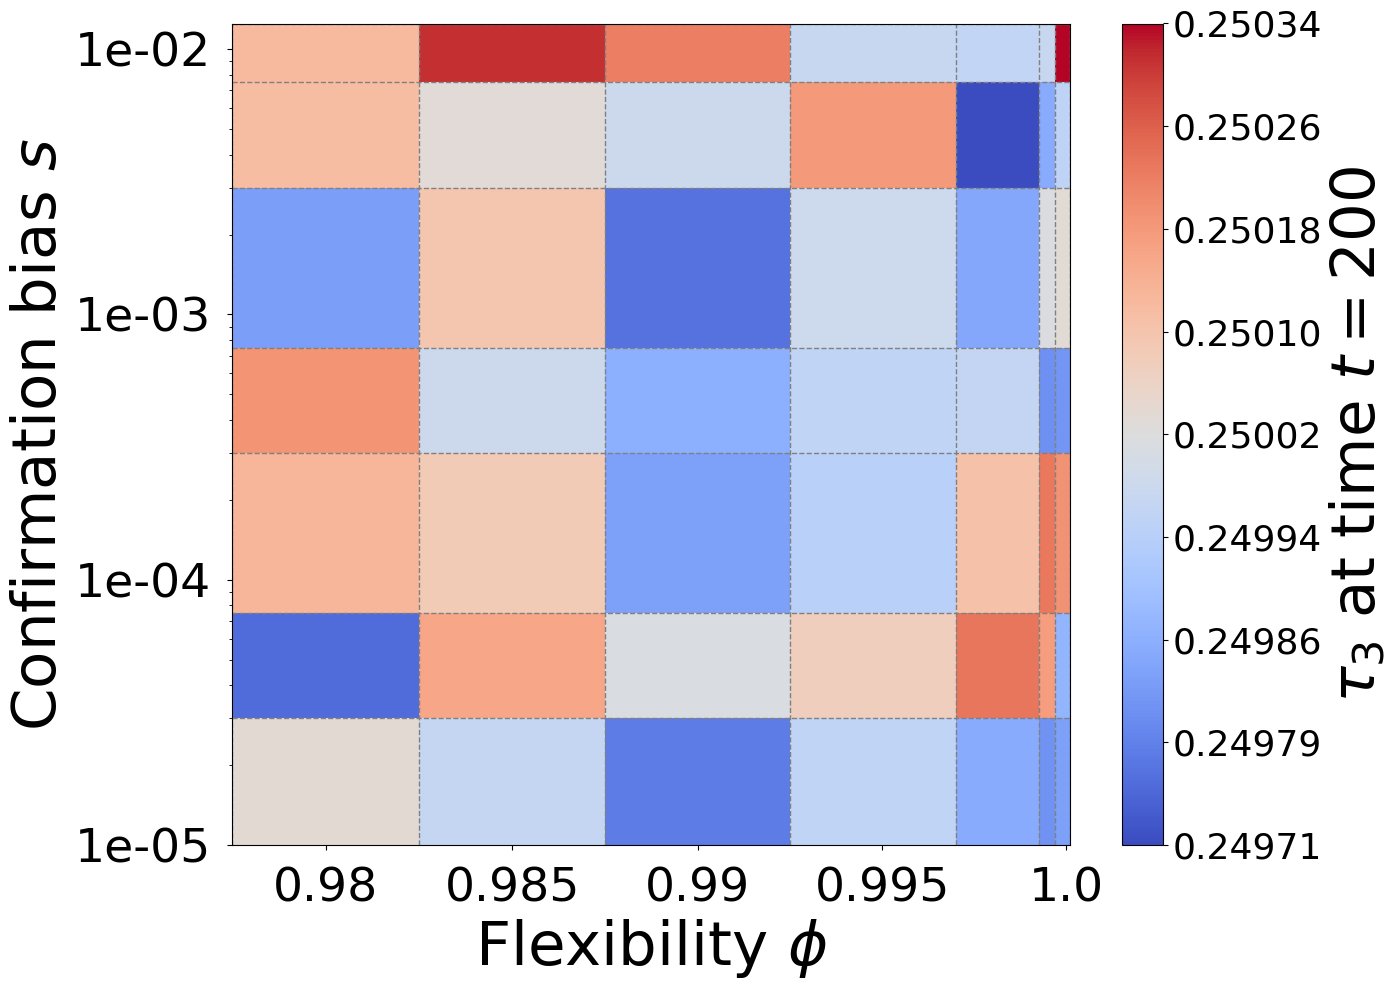

<Figure size 1400x1000 with 0 Axes>

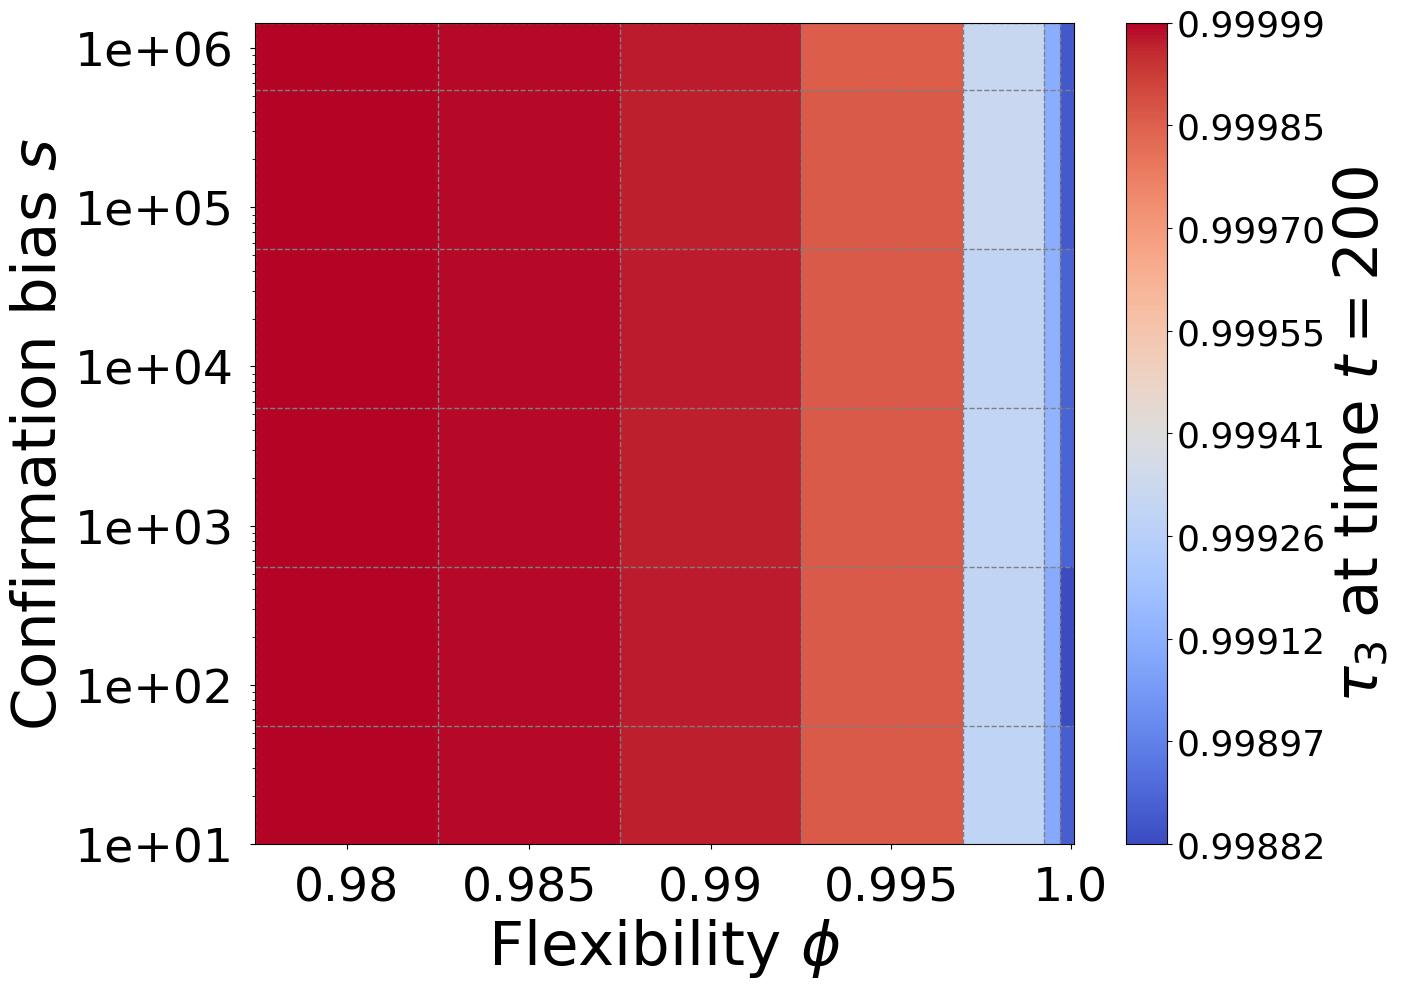

In [2]:
f_types = ["small", "large"]
s_types = ["small", "large"]
for f_type in f_types:
    for s_type in s_types:
        if s_type == "all" and f_type == "all":
            data_path = Path("summary_square_final_combined.csv")  # adjust if needed
        data_path = Path(f"combined_results/summary_square_final_{f_type}F_{s_type}S.csv")  # adjust if needed
        output_dir = Path("plots")
        output_dir.mkdir(exist_ok=True, parents=True)

        df = pd.read_csv(data_path)

        fs, ss = find_f_and_s(f_type, s_type)

        plot_critical(df, fs, ss, "T3", f"critical_phase_diagram_{f_type}F_{s_type}S_T3", output_dir)
        # plot_critical(df, fs, ss, "T2", f"critical_phase_diagram_{f_type}F_{s_type}S_T2", output_dir)
        # plot_critical(df, fs, ss, "T1", f"critical_phase_diagram_{f_type}F_{s_type}S_T1", output_dir)
        # plot_critical(df, fs, ss, "T0", f"critical_phase_diagram_{f_type}F_{s_type}S_T0", output_dir)

In [ ]:
f_type = "large"
s_type = "large"
if s_type == "all" and f_type == "all":
    data_path = Path("summary_square_final_combined.csv")  # adjust if needed
data_path = Path(f"combined_results/summary_square_final_{f_type}F_{s_type}S.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)
# X, Y = np.meshgrid(FLEX_STRENGTH_values, S_values)

df = pd.read_csv(data_path)
metric = "T3" 
pivot = df.pivot(index="S", columns="F", values=metric)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

vmin, vmax = 0.0, 1.0
n_bins = 20
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

pivot = pivot.sort_index(axis=0, ascending=False).sort_index(axis=1)

def compute_edges(arr):
    arr = np.asarray(arr)
    edges = (arr[:-1] + arr[1:]) / 2
    edges = np.concatenate([[arr[0] - (edges[0] - arr[0])], edges, [arr[-1] + (arr[-1] - edges[-1])]])
    return edges
y_ticks = [0.1, 0.6, 1.0, 2, 4, 8, 16]

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

vmin = np.nanmin(Z)
vmax = 1.0

mesh = ax.pcolormesh(
    x, y, Z,
    cmap="coolwarm",
    vmax=vmax
    # cmap=cmap,
    # norm=norm,
    # shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

bounds = np.linspace(vmin, vmax, 9)
# bounds = np.append(bounds, vmax)
print(bounds)
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_ticks(bounds)
cbar.set_ticklabels([f"{b:.5f}" for b in bounds])
cbar.set_label(f"Total system belief {metric[-1]}")

ax.set_yscale('log')
ax.set_xscale('log')
# plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel(r"Flexibility $\phi$", fontsize=24)
plt.ylabel(r"Confirmation bias $s$", fontsize=24)
plt.tight_layout()
out_path = output_dir / f"heatmap_logy_{metric}_{f_type}F_{s_type}S.png"
plt.savefig(out_path, dpi=300)
plt.show()

# plt.figure(figsize=(10, 6.7))
# fig, ax = plt.subplots(figsize=(10, 6.7))

# # Convert pivot to numpy
# Z = pivot.values
# x = pivot.columns.values
# y = pivot.index.values
# x_edges = compute_edges(x)
# y_edges = compute_edges(y)

# mesh = ax.pcolormesh(
#     x, y, Z,
#     cmap=cmap,
#     norm=norm,
#     shading="nearest"
# )
# for xv in x_edges:
#     ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
# for yv in y_edges:
#     ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

# cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
# cbar.set_label(f"Total system belief in hypothesis {metric[1]}")
# plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
# plt.xlabel("Flexibility strength (F)")
# plt.ylabel("Confirmation bias strength (s)")
# # plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
# # plt.yticks(y_ticks, fontsize=11)
# plt.tight_layout()
# out_path = output_dir / f"heatmap_{metric}.png"
# plt.savefig(out_path, dpi=300)
# plt.show()

print(f"✅ Saved heatmap to {out_path}")

In [ ]:
data_path = Path("combined_results/summary_square_final_large.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)
X, Y = np.meshgrid(FLEX_STRENGTH_values, S_values)

df = pd.read_csv(data_path)
metric = "T3" 
pivot = df.pivot(index="S", columns="F", values=metric)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

vmin, vmax = 0.0, 1.0
n_bins = 20
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm")
# norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

pivot = pivot.sort_index(axis=0, ascending=False).sort_index(axis=1)

def compute_edges(arr):
    arr = np.asarray(arr)
    edges = (arr[:-1] + arr[1:]) / 2
    edges = np.concatenate([[arr[0] - (edges[0] - arr[0])], edges, [arr[-1] + (arr[-1] - edges[-1])]])
    return edges
y_ticks = [0.1, 0.6, 1.0, 2, 4, 8, 16]

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    # norm=norm,
    vmin=0.999,
    vmax=1,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="black", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="black", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")

ax.set_yscale('log')
# ax.set_xscale('log')
plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
# plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
# plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"large_heatmap_logy_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

# plt.figure(figsize=(10, 6.7))
# fig, ax = plt.subplots(figsize=(10, 6.7))

# # Convert pivot to numpy
# Z = pivot.values
# x = pivot.columns.values
# y = pivot.index.values
# x_edges = compute_edges(x)
# y_edges = compute_edges(y)

# mesh = ax.pcolormesh(
#     x, y, Z,
#     cmap=cmap,
#     norm=norm,
#     shading="nearest"
# )
# for xv in x_edges:
#     ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
# for yv in y_edges:
#     ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

# cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
# cbar.set_label(f"Total system belief in hypothesis {metric[1]}")
# plt.title(fr"Heatmap of final Truthfulness $\tau_3$")
# plt.xlabel("Flexibility strength (F)")
# plt.ylabel("Confirmation bias strength (s)")
# # plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
# # plt.yticks(y_ticks, fontsize=11)
# plt.tight_layout()
# out_path = output_dir / f"heatmap_{metric}.png"
# plt.savefig(out_path, dpi=300)
# plt.show()

print(f"✅ Saved heatmap to {out_path}")

In [ ]:
# === Configuration ===
data_root = Path("combined_results")
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

metric = "T3"          # change to T1, T2, T3, or CD as needed
threshold = 1e-4       # convergence criterion
n_bins = 10            # discrete color levels
vmin, vmax = 0, 200    # timestep range for color scale (adjust to your simulation length)

# === Load all combined files ===
files = list(data_root.glob("COMBINED_S*_F*.npz"))
rows = []

for f in tqdm(files, desc="Processing combined files"):
    data = np.load(f)
    S, F = data["S"].item(), data["F"].item()
    arr = data[metric]
    final_val = arr[-1]

    # find first timestep within threshold of final value
    diffs = np.abs(arr - final_val)
    conv_idx = np.argmax(diffs < threshold) if np.any(diffs < threshold) else len(arr) - 1
    rows.append({"S": S, "F": F, "converged_at": conv_idx})

# === Build DataFrame ===
df = pd.DataFrame(rows)
pivot = df.pivot(index="S", columns="F", values="converged_at")
pivot = pivot.sort_index(axis=0).sort_index(axis=1)

# === Fixed discrete colormap ===
vmin, vmax = 0.0, 200
n_bins = 200
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

ax = sns.heatmap(
    pivot,
    cmap="coolwarm",
    vmin=np.min(df["converged_at"]),
    vmax=np.max(df["converged_at"]),
    # norm=norm,
    cbar_kws={
        "ticks": np.linspace(np.min(df["converged_at"]), 214, 15),
        "label": f"t at convergence for belief in hypothesis {metric[1]}",
    },
    linewidths=0.1,
    linecolor='black',
    square=True
)

# plt.title(f"Heatmap of {metric} (final timestep)")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
out_path = output_dir / f"convergence_heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()


print(f"✅ Saved convergence heatmap to {out_path}")
